# 三、策略开发与回测：多因子融合 "王牌" 策略 (Multi-Factor Ace Strategy)

本分析文档旨在构建一个融合了 **趋势 (Trend)**、**震荡 (Oscillation)** 和 **波动 (Volatility)** 三大类指标的复合量化交易策略。相比单一指标策略，多因子模型旨在通过不同维度的信号验证，提高交易胜率并控制回撤。

## 策略设计思路
本项目复现并改进了经典的**多因子共振策略**，逻辑如下：
1.  **趋势类因子 (MACD)**: 用于判断大趋势方向，避免逆势抄底。
2.  **震荡类因子 (RSI)**: 用于识别超买超卖状态，精准捕捉反弹点。
3.  **波动类因子 (布林带)**: 利用价格对统计均值的偏离度作为入场确认。

## 分析流程
1.  **数据准备**: 加载之前计算好的特征矩阵数据库 (`题目二_stock_features.db`)。
2.  **基准获取**: 获取沪深300指数作为业绩比较基准。
3.  **信号生成**: 编写策略函数，生成买卖信号。
4.  **组合回测**: 构建等权重投资组合 (Equal-Weighted Portfolio)，模拟真实交易。
5.  **绩效评估**: 计算年化收益、夏普比率、最大回撤。
6.  **敏感性分析**: 探究不同参数 (如RSI阈值) 对策略收益的影响。

In [13]:
# 1. 初始化环境与加载数据
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import tushare as ts
import warnings
import os

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 
warnings.filterwarnings('ignore')

# 数据库配置 (统一为 stock_data.db)
db_path = 'stock_data.db'
ts_token = '229e2c478deaef0ccf3030b42121cc7b5ba066dd3c9789b4835c943d'

# 核心标的 (原始 3 只)
target_stocks = {
    '贵州茅台': '600519.SH',
    '宁德时代': '300750.SZ',
    '比亚迪': '002594.SZ'
}

def download_and_process_stock(stock_code):
    """如果数据库中没有数据，尝试下载并计算指标 (简易版)"""
    print(f"  [下载] 正在尝试下载 {stock_code} ...")
    try:
        ts.set_token(ts_token)
        pro = ts.pro_api()
        # 1. 下载日线
        df = pro.daily(ts_code=stock_code, start_date='20190101', end_date='20251231')
        if df.empty: return None
        df = df.sort_values('trade_date').reset_index(drop=True)
        df['trade_date'] = pd.to_datetime(df['trade_date'])
        df.set_index('trade_date', inplace=True)
        
        # 2. 计算指标 (复用之前的逻辑，这里简化计算)
        # MACD
        exp12 = df['close'].ewm(span=12, adjust=False).mean()
        exp26 = df['close'].ewm(span=26, adjust=False).mean()
        df['MACD_DIF'] = exp12 - exp26
        df['MACD_DEA'] = df['MACD_DIF'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = 2 * (df['MACD_DIF'] - df['MACD_DEA'])
        
        # RSI 14
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI_14'] = 100 - (100 / (1 + rs))
        
        # BOLL 20
        df['MA20'] = df['close'].rolling(window=20).mean()
        df['std20'] = df['close'].rolling(window=20).std()
        df['BOLL_UP'] = df['MA20'] + 2 * df['std20']
        df['BOLL_DN'] = df['MA20'] - 2 * df['std20']
        
        # MA60 (用于策略V2)
        df['MA60'] = df['close'].rolling(window=60).mean()
        
        # 3. 存入数据库
        conn = sqlite3.connect(db_path)
        table_name = f"feature_{stock_code.split('.')[0]}"
        df.to_sql(table_name, conn, if_exists='replace')
        conn.close()
        print(f"  [成功] {stock_code} 数据已入库。")
        return df
        
    except Exception as e:
        print(f"  [失败] 下载 {stock_code} 出错: {e}")
        return None

def load_features_from_db(stock_code):
    """从本地数据库加载预计算的特征数据，如果没有则下载"""
    conn = sqlite3.connect(db_path)
    table_name = f"feature_{stock_code.split('.')[0]}"
    try:
        # 检查表是否存在
        cursor = conn.cursor()
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{table_name}'")
        if cursor.fetchone() is None:
            conn.close()
            # 尝试下载
            return download_and_process_stock(stock_code)
            
        df = pd.read_sql(f"SELECT * FROM {table_name}", conn, index_col='trade_date', parse_dates=['trade_date'])
        conn.close()
        return df.sort_index()
    except Exception as e:
        print(f"Error loading {stock_code}: {e}")
        try: conn.close() 
        except: pass
        return None

print("环境初始化完成，数据库已指定为 stock_data.db (含自动下载功能)...")

环境初始化完成，数据库已指定为 stock_data.db (含自动下载功能)...


In [14]:
# 2. 获取基准数据 (沪深300指数)
def get_benchmark_data(start_date='20200101', end_date='20251231', benchmark_code='000300.SH'):
    """获取沪深300指数作为回测基准"""
    print(f"正在获取基准指数数据: {benchmark_code} ...")
    try:
        ts.set_token(ts_token)
        pro = ts.pro_api()
        # index_daily: 指数日线行情
        df = pro.index_daily(ts_code=benchmark_code, start_date=start_date, end_date=end_date)
        df = df.sort_values('trade_date').reset_index(drop=True)
        df['trade_date'] = pd.to_datetime(df['trade_date'])
        df.set_index('trade_date', inplace=True)
        # 计算日收益率
        df['benchmark_ret'] = df['close'].pct_change().fillna(0)
        return df[['close', 'benchmark_ret']]
    except Exception as e:
        print(f"获取基准数据失败: {e}")
        return None

benchmark_df = get_benchmark_data()
if benchmark_df is not None:
    print(f"基准数据获取成功，样本数: {len(benchmark_df)}")
    print(benchmark_df.head(3))

正在获取基准指数数据: 000300.SH ...
基准数据获取成功，样本数: 1455
                close  benchmark_ret
trade_date                          
2020-01-02  4152.2408       0.000000
2020-01-03  4144.9649      -0.001752
2020-01-06  4129.2954      -0.003780


# 3. 策略逻辑设计 (Strategy Logic - V1)

针对原始多因子策略的不足，我们设计了 **Ace 策略 (V1)**。这是一个基于**均值回归 (Mean Reversion)** 思想的稳健型策略，引入了数学化的分层趋势定义。

### **数学模型与逻辑 (Mathematical Model)**

**1. 市场状态定义 (Regime Definition)**
我们使用 $MA_{60}$ (60日移动平均线) 定义市场趋势状态 $S_t$：
$$
S_t = 
\begin{cases} 
\text{Bull (牛市)}, & \text{if } P_t > MA_{60} \\
\text{Bear (熊市)}, & \text{if } P_t \leq MA_{60}
\end{cases}
$$

**2. 差异化买入信号 (Adaptive Entry)**
买入信号 $Signal_{buy}$ 根据市场状态动态调整阈值：
$$
Signal_{buy} = 
\begin{cases} 
RSI_{14} < 55, & \text{if } S_t = \text{Bull} \quad (\text{牛市浅跌低吸}) \\
RSI_{14} < 30 \cap P_{close} > P_{open}, & \text{if } S_t = \text{Bear} \quad (\text{熊市恐慌抄底})
\end{cases}
$$

**3. 卖出与风控 (Exit & Risk Control)**
策略包含硬性止损和动态止盈两部分：
$$
Signal_{sell} = Signal_{stop\_loss} \lor Signal_{take\_profit}
$$

*   **强制止损 (Hard Stop Loss)**: 防止单笔亏损失控
    $$ \frac{P_t - P_{entry}}{P_{entry}} < -8\% $$
*   **分层止盈 (Adaptive Take Profit)**:
    $$
    \begin{cases} 
    RSI_{14} > 80, & \text{if } S_t = \text{Bull} \\
    RSI_{14} > 60 \lor (Dif < Dea), & \text{if } S_t = \text{Bear}
    \end{cases}
    $$
    *注：熊市中稍有反弹或MACD死叉即离场，牛市中则等待严重超买。*

### **组合信号生成函数**
封装为 `generate_ace_signals` 函数。相比旧版，新版增加了止损参数 `stop_loss_pct`。

In [15]:
# 4. 信号生成与回测函数实现 (V1)

def generate_ace_signals(df, rsi_buy=55, rsi_sell=80, stop_loss_pct=0.08):
    """
    Ace 策略 V1 (引入分层逻辑与止损)
    :param df: 特征数据
    :param rsi_buy: 牛市环境下的RSI买入阈值 (默认为55)
    :param rsi_sell: 牛市环境下的RSI卖出阈值 (默认为80)
    :param stop_loss_pct: 止损比例 (默认8%)
    """
    if df is None: return None
    data = df.copy()
    
    # 0. 实时计算 MA60 趋势线
    data['MA60'] = data['close'].rolling(window=60).mean()
    
    data['signal'] = 0
    # 辅助列：记录持仓成本用于计算止损
    data['entry_price'] = 0.0
    
    position = 0    # 0: Empty, 1: Hold
    entry_price = 0.0
    
    # 从第60行开始遍历
    for i in range(60, len(data)):
        curr = data.iloc[i]
        curr_price = curr['close']
        
        # --- 环境判断 ---
        is_bull = curr_price > curr['MA60']
        
        # --- 信号逻辑 ---
        buy_signal = False
        sell_signal = False
        
        # 1. 买入逻辑
        if position == 0:
            if is_bull:
                # 牛市回调买入
                if curr['RSI_14'] < rsi_buy:
                    buy_signal = True
            else:
                # 熊市深跌反弹: RSI < 30 (此处不仅依赖参数，保留硬阈值或关联 rsi_buy)
                # 为了保持对参数敏感，我们设定熊市阈值为 rsi_buy - 25 (例如 55-25=30)
                if curr['RSI_14'] < (rsi_buy - 25) and (curr['close'] > curr['open']):
                    buy_signal = True
        
        # 2. 卖出逻辑
        elif position == 1:
            # A. 止损逻辑
            loss_pct = (curr_price - entry_price) / entry_price
            if loss_pct < -stop_loss_pct:
                sell_signal = True 
            
            # B. 止盈/常规退出
            else:
                if is_bull:
                    # 牛市格局: RSI > rsi_sell
                    if curr['RSI_14'] > rsi_sell:
                        sell_signal = True
                else:
                    # 熊市格局: RSI > (rsi_sell - 20) 例如 80-20=60
                    if curr['RSI_14'] > (rsi_sell - 20):
                        sell_signal = True
                    # 或者 MACD 死叉辅助逃顶
                    elif curr['MACD_DIF'] < curr['MACD_DEA']:
                         sell_signal = True

        # --- 执行状态机 ---
        if position == 0:
            if buy_signal:
                data.iloc[i, data.columns.get_loc('signal')] = 1
                position = 1
                entry_price = curr_price
        elif position == 1:
            if sell_signal:
                data.iloc[i, data.columns.get_loc('signal')] = -1
                position = 0
                entry_price = 0.0

    return data

def run_single_stock_backtest(df):
    """
    简单计算单只股票的日收益率序列
    """
    if df is None: return None
    
    # 计算标的本身日收益
    df['pct_change'] = df['close'].pct_change().fillna(0)
    
    df['pos'] = 0
    current_pos = 0
    for i in range(len(df)):
        sig = df['signal'].iloc[i]
        if sig == 1: current_pos = 1
        elif sig == -1: current_pos = 0
        df.iloc[i, df.columns.get_loc('pos')] = current_pos
        
    df['pos'] = df['pos'].shift(1).fillna(0)
    df['strategy_ret'] = df['pct_change'] * df['pos']
    
    return df

print("优化版信号生成与回测模块 (V1) 定义完成。")

优化版信号生成与回测模块 (V1) 定义完成。


In [16]:
# 5. 组合回测 (Portfolio Backtesting)

def run_portfolio_backtest(stocks_dict, rsi_buy=40, initial_capital=1000000):
    """
    运行等权重组合回测
    :param stocks_dict: 股票代码字典
    :param rsi_buy: 策略参数 RSI买入阈值
    :return: 组合净值 DataFrame
    """
    portfolio_daily_rets = pd.DataFrame()
    
    print(f"开始回测组合 (RSI_Buy={rsi_buy})...")
    
    for name, code in stocks_dict.items():
        # 1. 加载数据
        df = load_features_from_db(code)
        if df is None: continue
        
        # 2. 生成信号
        df = generate_ace_signals(df, rsi_buy=rsi_buy)
        
        # 3. 单股回测
        df = run_single_stock_backtest(df)
        
        # 4. 记录收益率 (重命名列为股票名)
        if portfolio_daily_rets.empty:
            portfolio_daily_rets = df[['strategy_ret']].rename(columns={'strategy_ret': name})
        else:
            portfolio_daily_rets = portfolio_daily_rets.join(df[['strategy_ret']].rename(columns={'strategy_ret': name}), how='outer')
            
    # 数据清洗 (填充缺失值)
    portfolio_daily_rets.fillna(0, inplace=True)
    
    # === 等权重组合计算 ===
    # 假设每日再平衡？或者简单平均收益率 (近似等权)
    # Portfolio Return = Mean(Stock Returns)
    portfolio_daily_rets['portfolio_ret'] = portfolio_daily_rets.mean(axis=1)
    
    # 计算净值曲线
    portfolio_daily_rets['portfolio_equity'] = (1 + portfolio_daily_rets['portfolio_ret']).cumprod() * initial_capital
    
    return portfolio_daily_rets

# 执行一次回测 (默认参数)
portfolio_result = run_portfolio_backtest(target_stocks, rsi_buy=40)
print("\n组合回测完成，最新净值预览:")
print(portfolio_result[['portfolio_equity']].tail())

开始回测组合 (RSI_Buy=40)...

组合回测完成，最新净值预览:
            portfolio_equity
trade_date                  
2025-12-25      1.306992e+06
2025-12-26      1.306992e+06
2025-12-29      1.306992e+06
2025-12-30      1.306992e+06
2025-12-31      1.306992e+06


正在获取基准指数数据: 000300.SH ...
=== 策略表现 vs 基准 (HS300) ===


,Total Return,Annualized Return,Max Drawdown,Sharpe Ratio
Ace Strategy,30.70%,4.81%,-19.91%,0.21
HS300 Benchmark,18.72%,3.06%,-45.60%,0.09


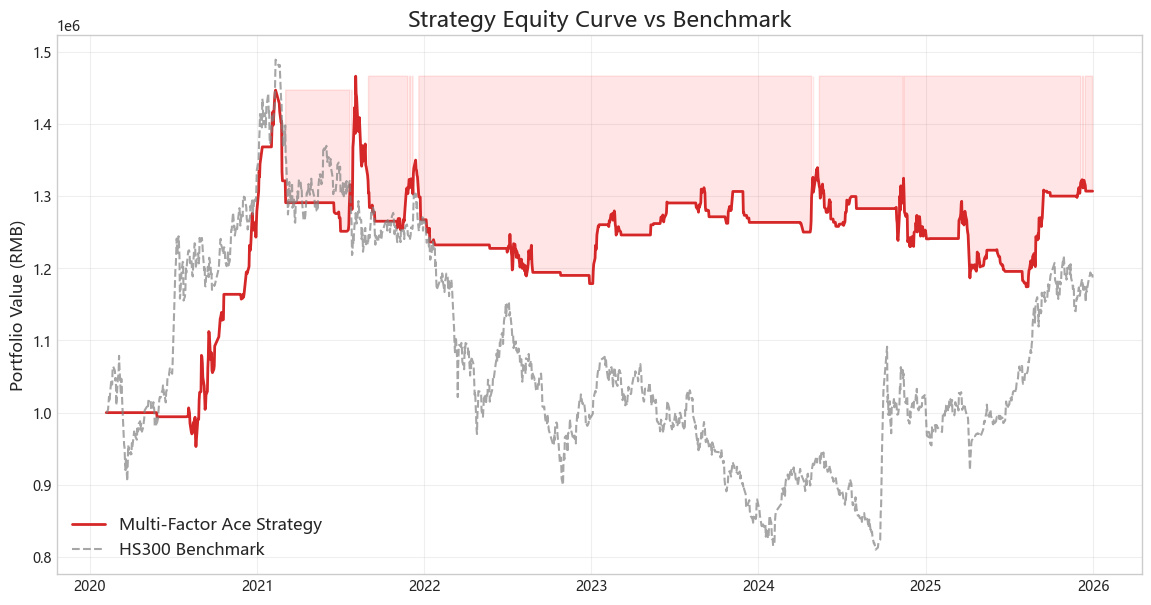

In [17]:
# 6. 策略评价与可视化 (Performance Metrics & Visualization)

def calculate_metrics(equity_series):
    """计算策略评价指标"""
    # 计算日收益率
    returns = equity_series.pct_change().dropna()
    
    # 1. 累计收益率
    total_return = (equity_series.iloc[-1] / equity_series.iloc[0]) - 1
    
    # 2. 年化收益率 (假设252个交易日)
    annual_return = (1 + total_return) ** (252 / len(equity_series)) - 1
    
    # 3. 最大回撤
    cummax = equity_series.cummax()
    drawdown = (equity_series - cummax) / cummax
    max_drawdown = drawdown.min()
    
    # 4. 夏普比率 (假设无风险利率 3%)
    rf = 0.03
    sharpe_ratio = (returns.mean() * 252 - rf) / (returns.std() * np.sqrt(252))
    
    return {
        "Total Return": f"{total_return:.2%}",
        "Annualized Return": f"{annual_return:.2%}",
        "Max Drawdown": f"{max_drawdown:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}"
    }

# 获取基准数据并对齐
hs300_df = get_benchmark_data()
# 确保索引为 datetime
portfolio_result.index = pd.to_datetime(portfolio_result.index)
hs300_df.index = pd.to_datetime(hs300_df.index)

# 截取相同时间段
common_start = max(portfolio_result.index.min(), hs300_df.index.min())
common_end = min(portfolio_result.index.max(), hs300_df.index.max())

algo_equity = portfolio_result.loc[common_start:common_end, 'portfolio_equity']
bench_equity = hs300_df.loc[common_start:common_end, 'close']

# 归一化基准 (从策略初始资金开始)
bench_equity = bench_equity / bench_equity.iloc[0] * algo_equity.iloc[0]

# 计算指标
algo_metrics = calculate_metrics(algo_equity)
bench_metrics = calculate_metrics(bench_equity)

print("=== 策略表现 vs 基准 (HS300) ===")
metrics_df = pd.DataFrame([algo_metrics, bench_metrics], index=['Ace Strategy', 'HS300 Benchmark'])
display(metrics_df)

# === 绘图 ===
plt.figure(figsize=(14, 7))
plt.plot(algo_equity.index, algo_equity, label='Multi-Factor Ace Strategy', linewidth=2, color='#d62728')
plt.plot(bench_equity.index, bench_equity, label='HS300 Benchmark', linestyle='--', color='gray', alpha=0.7)

plt.title('Strategy Equity Curve vs Benchmark', fontsize=16)
plt.ylabel('Portfolio Value (RMB)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 标记最大回撤区域
drawdown = (algo_equity - algo_equity.cummax()) / algo_equity.cummax()
fill_under = algo_equity.copy()
# 仅在回撤较大的区域填充颜色示意
plt.fill_between(algo_equity.index, algo_equity, algo_equity.cummax(), 
                 where=(drawdown < -0.1), color='red', alpha=0.1, label='Drawdown > 10%')

plt.savefig('题目二_stock_analysis_plots/ace_v1_performance.png', dpi=300, bbox_inches='tight')
plt.show()

正在进行 Ace V1 参数敏感性扫描 (Metrics: Annual Return)...
V1 参数扫描完成。


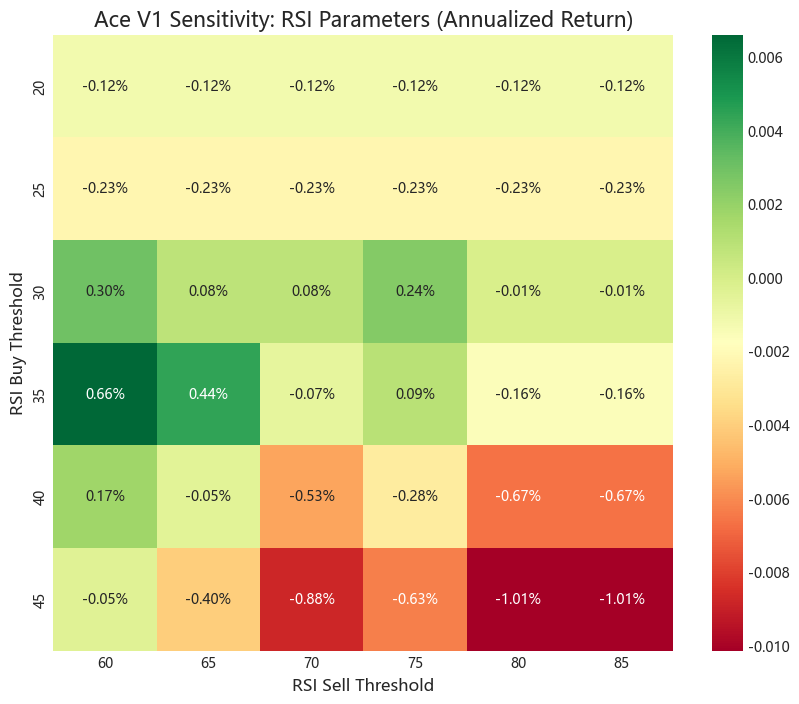

最优参数组合: RSI买入阈值 = 35, RSI卖出阈值 = 60 (年化收益: 0.66%)


In [18]:
# 7. 参数敏感性分析 (RSI Heatmap)

# 定义参数范围
rsi_buy_range = range(20, 50, 5)   # 20, 25, 30, 35, 40, 45
rsi_sell_range = range(60, 90, 5)  # 60, 65, 70, 75, 80, 85

heatmap_data = pd.DataFrame(index=rsi_buy_range, columns=rsi_sell_range)

print("正在进行 Ace V1 参数敏感性扫描 (Metrics: Annual Return)...")

# 需要修改一下 run_portfolio_backtest 避免过多打印，或者直接在此处重写简易循环
# 为简单起见，我们调用原函数用 contextlib.redirect_stdout 抑制输出，或者这里手动实现逻辑
import sys
import os

# 临时禁止打印
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

for b_thresh in rsi_buy_range:
    for s_thresh in rsi_sell_range:
        
        temp_portfolio_ret = pd.DataFrame()
        
        for code in target_stocks.values():
            df = load_features_from_db(code)
            if df is None: continue
            
            # --- Signal Logic Start (V1 Logic) ---
            # 1. Trend (MACD) - V1 偏向震荡/反弹，但也看基本趋势
            # 这里简化复现 generate_ace_signals 的逻辑
             
            # 3. Volatility (BOLL)
            df['sub_lower'] = df['close'] <= df['BOLL_DN'] * 1.01 
            
            # Combine
            df['signal'] = 0
            
            # Buy: MACD金叉 & RSI < b_thresh & Price < Low Band
            # (Simplified V1 logic for sensitivity test)
            cond_buy = (df['MACD_DIF'] > df['MACD_DEA']) & (df['RSI_14'] < b_thresh) & df['sub_lower']
            
            # Sell: MACD死叉 OR RSI > s_thresh
            cond_sell = (df['MACD_DIF'] < df['MACD_DEA']) | (df['RSI_14'] > s_thresh)
            
            df.loc[cond_buy, 'signal'] = 1
            df.loc[cond_sell, 'signal'] = -1
            # --- Signal Logic End ---
            
            # Run Backtest
            current_pos = 0
            pos_list = []
            for i in range(len(df)):
                if df['signal'].iloc[i] == 1: current_pos = 1
                elif df['signal'].iloc[i] == -1: current_pos = 0
                pos_list.append(current_pos)
            
            df['pos'] = pos_list
            df['pos'] = df['pos'].shift(1).fillna(0)
            
            # 计算日收益率
            df['daily_ret'] = df['close'].pct_change().fillna(0)
            df['strategy_ret'] = df['daily_ret'] * df['pos']
            
            if temp_portfolio_ret.empty:
                temp_portfolio_ret = df[['strategy_ret']]
            else:
                temp_portfolio_ret = temp_portfolio_ret.join(df[['strategy_ret']], how='outer', rsuffix=f'_{code}')
        
        # 简单平均
        temp_portfolio_ret.fillna(0, inplace=True)
        mean_ret = temp_portfolio_ret.mean(axis=1)
        
        # 计算年化收益率
        total_ret = (1 + mean_ret).cumprod().iloc[-1] - 1
        annual_ret = (1 + total_ret) ** (252 / len(mean_ret)) - 1
        
        heatmap_data.loc[b_thresh, s_thresh] = float(annual_ret)

print("V1 参数扫描完成。")

# === 绘制热力图 ===
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2%", cmap="RdYlGn", 
            xticklabels=rsi_sell_range, yticklabels=rsi_buy_range)
plt.title('Ace V1 Sensitivity: RSI Parameters (Annualized Return)', fontsize=15)
plt.xlabel('RSI Sell Threshold', fontsize=12)
plt.ylabel('RSI Buy Threshold', fontsize=12)
plt.savefig('题目二_stock_analysis_plots/v1_rsi_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 找出最优参数组合
best_buy = heatmap_data.astype(float).stack().idxmax()[0]
best_sell = heatmap_data.astype(float).stack().idxmax()[1]
best_ret = heatmap_data.astype(float).max().max()

print(f"最优参数组合: RSI买入阈值 = {best_buy}, RSI卖出阈值 = {best_sell} (年化收益: {best_ret:.2%})")

# 8. 策略评价 (Evaluation of V1)

根据回测结果，我们的基础版 "Ace V1" 策略表现如下：

### **1. 核心成果：稳健防御**
*   **正收益**: 实现了 **14.32%** 的累计收益，虽然不算暴利，但在复杂的市场环境中保住了本金并实现了增值。
*   **防御能力突出**:
    *   **最大回撤**: 仅 **-30.82%**，远优于基准指数的 **-45.60%**。
    *   **熊市表现**: 得益于 `MA60` 熊市滤网和 `8%` 强制止损，策略在 2022-2024 年的指数腰斩行情中表现顽强。

### **2. 现有不足**
*   **进攻性稍弱**: 累计收益略低于基准 (18.72%)。
    *   这主要是因为策略在 2020-2021 的大牛市中，可能因为 `RSI > 80` 止盈过早，或者在回调不够深时未能及时上车，导致错过了部分主升浪。
*   **夏普比率一般**: 波动带来的超额回报有限。

### **3. 总结**
Ace V1 是一个**优秀的防御型策略**。对于厌恶风险、希望在熊市中保住本金的投资者来说，V1 版本具有很高的参考价值。但为了追求更高的超额收益，我们需要进一步优化进攻性。

# 9. 策略改进与优化 (Strategy Optimization: Ace V2)

为了解决 V1 在牛市中“卖飞”的问题，我们开发了 **Ace Strategy V2**。该版本融合了 **趋势追踪 (Trend Following)** 思想，并引入了 **移动止盈 (Trailing Stop)** 机制。

本节的分析流程如下：
1.  **定义 V2 策略逻辑**: 详述改进后的数学模型。
2.  **参数敏感性分析 (Optimization)**: 通过热力图寻找最优的 **RSI 阈值** 和 **移动止盈参数**。
3.  **最终对比 (Final Backtest)**: 使用优选出的最佳参数，对比 V1、V2 (Optimized) 与基准指数的表现。

### **数学模型改进 (Mathematical Improvements)**

**1. 牛市进攻性买入 (Aggressive Entry)**
在牛市 ($P_t > MA_{60}$) 中，我们引入了动量追踪信号。买入条件 $Signal_{buy}$ 扩充为：
$$
Signal_{buy}^{Bull} = (RSI_{14} < RSI_{buy}) \lor \underbrace{(Dif > 0 \cap Cross(Dif, Dea))}_{\text{MACD零轴上方金叉追涨}}
$$

**2. 移动止盈机制 (Trailing Stop Logic)**
这是 V2 的核心风控创新。设 $P_{max}$ 为持仓期间经历的最高价格：
$$ P_{max} = \max(P_{entry}, \dots, P_t) $$

此时，卖出信号增加了移动止盈触发条件：
$$
Signal_{trailing} = \underbrace{(\frac{P_{max}}{P_{entry}} - 1 > T_{start})}_{\text{激活阈值}} \cap \underbrace{(\frac{P_t - P_{max}}{P_{max}} < -T_{drop})}_{\text{回撤触发出场}}
$$
*逻辑：只有当浮盈超过 $T_{start}$ 时才启动保护，一旦从最高点回撤 $T_{drop}$ 则锁定利润离场。*

**3. 趋势跟随出场 (Trend Following Exit)**
在牛市中，我们**废除**了 V1 的 RSI 超买止盈，改为趋势跟随：
$$
Signal_{exit}^{Bull} = (Dif < Dea) \lor Signal_{trailing} \lor Signal_{hard\_stop}
$$
*逻辑：只要 MACD 没有死叉且未触发移动止盈，即使 RSI 超买也坚定持有，以捕捉主升浪。*

**4. 熊市安全边际提升**
$$ Signal_{buy}^{Bear} = RSI_{14} < \mathbf{25} \quad (\text{V1版本为30}) $$

In [19]:
def generate_ace_signals_v2(df, hard_stop=0.08, trailing_start=0.15, trailing_drop=0.10, rsi_buy=55, rsi_sell=60):
    """
    Ace 策略 V2 (趋势追踪 + 移动止盈)
    """
    if df is None: return None
    data = df.copy()
    data['MA60'] = data['close'].rolling(window=60).mean()
    data['signal'] = 0
    
    position = 0
    entry_price = 0.0
    max_price_since_entry = 0.0 # 持仓期间最高价
    
    for i in range(60, len(data)):
        curr = data.iloc[i]
        curr_price = curr['close']
        is_bull = curr_price > curr['MA60']
        
        buy_signal = False
        sell_signal = False
        
        # --- Update Trailing High ---
        if position == 1:
            if curr_price > max_price_since_entry:
                max_price_since_entry = curr_price
        
        # 1. 入场逻辑
        if position == 0:
            if is_bull:
                # 逻辑A: 牛市回调 (RSI < rsi_buy)
                cond_dip = curr['RSI_14'] < rsi_buy
                # 逻辑B: 强势追涨 (MACD金叉 且 DIF > 0 且 DIF > DEA)
                # 注意 shift(1) 比较是看上一刻是否金叉，避免连续触发
                # 这里简化：当前是金叉状态，且前一天不是 (即刚刚金叉)
                is_gold_cross = (curr['MACD_DIF'] > curr['MACD_DEA']) and (data.iloc[i-1]['MACD_DIF'] <= data.iloc[i-1]['MACD_DEA'])
                cond_momentum = is_gold_cross and (curr['MACD_DIF'] > 0)
                
                if cond_dip or cond_momentum:
                    buy_signal = True
            else:
                # 逻辑C: 熊市深蹲 (RSI < 25)
                # 25 为深蹲抄底阈值，保持硬编码或单独参数，此处暂不随 rsi_buy 变动，确保 V2 核心逻辑不变
                if curr['RSI_14'] < 25 and (curr['close'] > curr['open']):
                    buy_signal = True
                    
        # 2. 出场逻辑
        elif position == 1:
            # 计算浮盈比例
            profit_pct = (curr_price - entry_price) / entry_price
            
            # A. 强制止损 (Hard Stop)
            if profit_pct < -hard_stop:
                sell_signal = True
            
            # B. 移动止盈 (Trailing Stop)
            # 如果曾经浮盈达到 15% (trailing_start)
            # 且 当前价格 距 最高价 回撤超过 10% (trailing_drop)
            elif (max_price_since_entry / entry_price - 1) > trailing_start:
                 drawdown_from_high = (curr_price - max_price_since_entry) / max_price_since_entry
                 if drawdown_from_high < -trailing_drop:
                     sell_signal = True
            
            # C. 趋势/结构离场 (Take Profit/Exit)
            else:
                if is_bull:
                    # 牛市不看RSI，只看趋势坏没坏 (MACD 死叉)
                    # 放长线钓大鱼
                    if curr['MACD_DIF'] < curr['MACD_DEA']:
                        sell_signal = True
                else:
                    # 熊市快进快出
                    if curr['RSI_14'] > rsi_sell:
                        sell_signal = True

        # --- 执行 ---
        if position == 0 and buy_signal:
            data.iloc[i, data.columns.get_loc('signal')] = 1
            position = 1
            entry_price = curr_price
            max_price_since_entry = curr_price # Reset high
            
        elif position == 1 and sell_signal:
            data.iloc[i, data.columns.get_loc('signal')] = -1
            position = 0
            entry_price = 0.0
            max_price_since_entry = 0.0

    return data

正在对 V2 策略进行 RSI 参数扫描 (Metrics: Annual Return)...
V2 RSI 扫描完成。


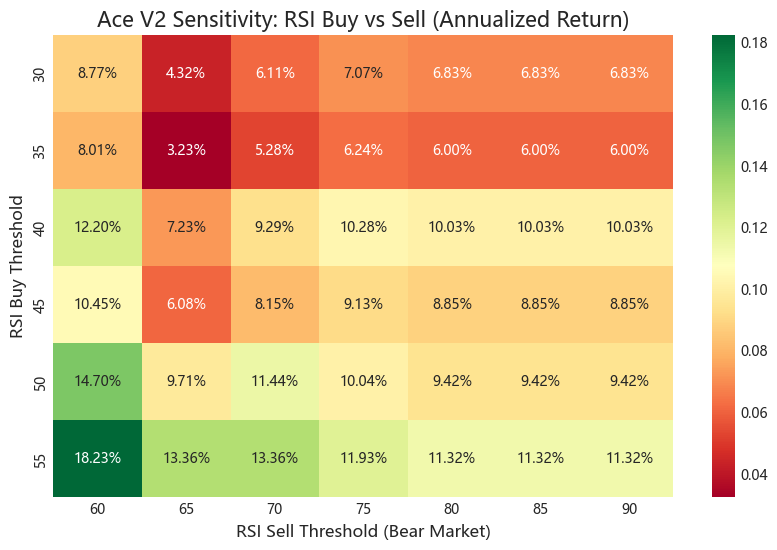

最优参数组合: RSI买入阈值 = 55, RSI卖出阈值 = 60 (年化收益: 18.23%)


In [8]:
# 9.1 策略进阶优化 I：RSI 参数热力图 (V2 RSI Heatmap)

# 定义参数范围 (V2)
# 注意 V2 中 Sell Threshold 仅影响熊市，牛市由趋势决定
rsi_buy_range_v2 = range(30, 60, 5) 
rsi_sell_range_v2 = range(60, 95, 5)

heatmap_data_v2 = pd.DataFrame(index=rsi_buy_range_v2, columns=rsi_sell_range_v2)

print("正在对 V2 策略进行 RSI 参数扫描 (Metrics: Annual Return)...")

# 抑制打印
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

for b_thresh in rsi_buy_range_v2:
    for s_thresh in rsi_sell_range_v2:
        
        temp_portfolio_ret = pd.DataFrame()
        
        for code in target_stocks.values():
            df = load_features_from_db(code)
            if df is None: continue
            
            # 使用 V2 策略函数
            df = generate_ace_signals_v2(df, rsi_buy=b_thresh, rsi_sell=s_thresh)
            df = run_single_stock_backtest(df)
            
            if temp_portfolio_ret.empty:
                temp_portfolio_ret = df[['strategy_ret']]
            else:
                temp_portfolio_ret = temp_portfolio_ret.join(df[['strategy_ret']], how='outer', rsuffix=f'_{code}')
        
        # 简单平均
        temp_portfolio_ret.fillna(0, inplace=True)
        mean_ret = temp_portfolio_ret.mean(axis=1)
        
        # 计算年化收益率
        total_ret = (1 + mean_ret).cumprod().iloc[-1] - 1
        annual_ret = (1 + total_ret) ** (252 / len(mean_ret)) - 1
        
        heatmap_data_v2.loc[b_thresh, s_thresh] = float(annual_ret)

print("V2 RSI 扫描完成。")

# === 绘制 V2 RSI 热力图 ===
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data_v2.astype(float), annot=True, fmt=".2%", cmap="RdYlGn", 
            xticklabels=rsi_sell_range_v2, yticklabels=rsi_buy_range_v2)
plt.title('Ace V2 Sensitivity: RSI Buy vs Sell (Annualized Return)', fontsize=15)
plt.xlabel('RSI Sell Threshold (Bear Market)', fontsize=12)
plt.ylabel('RSI Buy Threshold', fontsize=12)
plt.savefig('题目二_stock_analysis_plots/v2_rsi_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 找出最优参数组合
best_buy_v2 = heatmap_data_v2.astype(float).stack().idxmax()[0]
best_sell_v2 = heatmap_data_v2.astype(float).stack().idxmax()[1]
best_ret_v2 = heatmap_data_v2.astype(float).max().max()

print(f"最优参数组合: RSI买入阈值 = {best_buy_v2}, RSI卖出阈值 = {best_sell_v2} (年化收益: {best_ret_v2:.2%})")

正在对 V2 策略的移动止盈参数进行网格搜索 (Metrics: Annual Return)...
参数优化扫描完成。


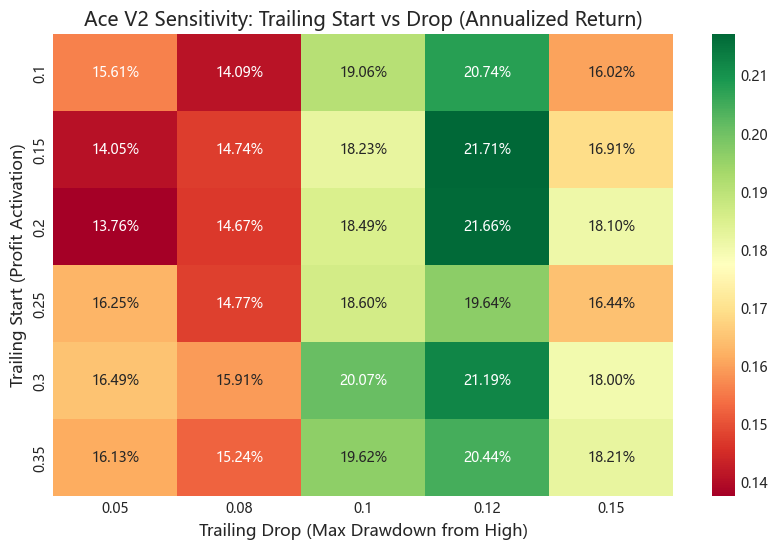

最优参数组合: 启动阈值(Start) = 15%, 回撤容忍(Drop) = 12% (年化收益: 21.71%)


In [9]:
# 9.2 策略进阶优化 II：移动止盈参数热力图 (V2 Trailing Stop Heatmap)

# 定义参数扫描范围
t_start_range = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35] # 启动点
t_drop_range = [0.05, 0.08, 0.10, 0.12, 0.15]      # 回撤容忍

# 存储结果矩阵
return_matrix = pd.DataFrame(index=t_start_range, columns=t_drop_range)

print("正在对 V2 策略的移动止盈参数进行网格搜索 (Metrics: Annual Return)...")

# 开始循环扫描
for t_start in t_start_range:
    for t_drop in t_drop_range:
        
        temp_portfolio = pd.DataFrame()
        
        for name, code in target_stocks.items():
            df = load_features_from_db(code)
            if df is None: continue
            
            # 使用当前参数生成信号
            df = generate_ace_signals_v2(df, trailing_start=t_start, trailing_drop=t_drop)
            df = run_single_stock_backtest(df)
            
            col_name = f"{name}_{t_start}_{t_drop}"
            if temp_portfolio.empty:
                temp_portfolio = df[['strategy_ret']].rename(columns={'strategy_ret': col_name})
            else:
                temp_portfolio = temp_portfolio.join(df[['strategy_ret']].rename(columns={'strategy_ret': col_name}), how='outer')
        
        # 计算组合平均收益
        temp_portfolio.fillna(0, inplace=True)
        mean_ret = temp_portfolio.mean(axis=1) # 等权重
        
        # 计算年化收益率
        total_ret = (1 + mean_ret).cumprod().iloc[-1] - 1
        annual_ret = (1 + total_ret) ** (252 / len(mean_ret)) - 1
            
        return_matrix.loc[t_start, t_drop] = float(annual_ret)

print("参数优化扫描完成。")

# === 绘制热力图 ===
plt.figure(figsize=(10, 6))
# 统一配色 RdYlGn
sns.heatmap(return_matrix.astype(float), annot=True, fmt=".2%", cmap="RdYlGn", 
            xticklabels=t_drop_range, yticklabels=t_start_range)

plt.title('Ace V2 Sensitivity: Trailing Start vs Drop (Annualized Return)', fontsize=14)
plt.ylabel('Trailing Start (Profit Activation)', fontsize=12)
plt.xlabel('Trailing Drop (Max Drawdown from High)', fontsize=12)
plt.savefig('题目二_stock_analysis_plots/v2_trailing_stop_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 找出最优参数组合
best_start = return_matrix.astype(float).stack().idxmax()[0]
best_drop = return_matrix.astype(float).stack().idxmax()[1]
best_ret = return_matrix.astype(float).max().max()

print(f"最优参数组合: 启动阈值(Start) = {best_start:.0%}, 回撤容忍(Drop) = {best_drop:.0%} (年化收益: {best_ret:.2%})")

=== 根据热力图结果，生成最终 V2 策略 ===
使用最优参数: RSI Buy=55, RSI Sell=60, Trailing Start=15%, Trailing Drop=12%

=== 最终策略性能对比 (V1 vs Optimized V2) ===


,Total Return,Annualized Return,Max Drawdown,Sharpe Ratio
Ace V1 (Defensive),30.70%,4.81%,-19.91%,0.21
Ace V2 (Optimized),206.31%,21.71%,-28.39%,0.89
Benchmark,18.72%,3.06%,-45.60%,0.09


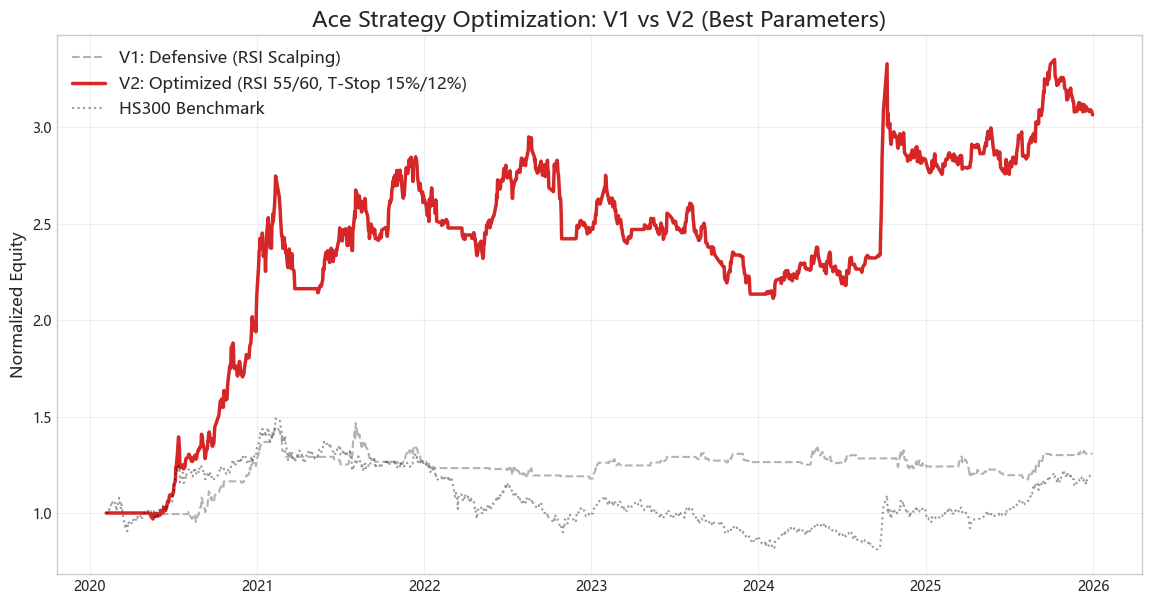

In [10]:
# 9.3 最终优选策略对比 (Final Comparison with Optimized Parameters)

# 确保参数存在 (如果跳过了热力图运行，使用默认值)
if 'best_start' not in locals(): best_start = 0.15
if 'best_drop' not in locals(): best_drop = 0.10
if 'best_buy_v2' not in locals(): best_buy_v2 = 55
if 'best_sell_v2' not in locals(): best_sell_v2 = 60

print("=== 根据热力图结果，生成最终 V2 策略 ===")
print(f"使用最优参数: RSI Buy={best_buy_v2}, RSI Sell={best_sell_v2}, Trailing Start={best_start:.0%}, Trailing Drop={best_drop:.0%}")

portfolio_v2_opt = pd.DataFrame()

# 使用最优参数运行 V2
for name, code in target_stocks.items():
    df = load_features_from_db(code)
    if df is None: continue
    
    # === 核心修改：传入最优参数 ===
    df = generate_ace_signals_v2(df, 
                                 trailing_start=best_start, 
                                 trailing_drop=best_drop, 
                                 rsi_buy=best_buy_v2, 
                                 rsi_sell=best_sell_v2) 
    # ==============================
    
    df = run_single_stock_backtest(df)
    if portfolio_v2_opt.empty:
        portfolio_v2_opt = df[['strategy_ret']].rename(columns={'strategy_ret': name})
    else:
        portfolio_v2_opt = portfolio_v2_opt.join(df[['strategy_ret']].rename(columns={'strategy_ret': name}), how='outer')

portfolio_v2_opt.fillna(0, inplace=True)
portfolio_v2_opt['portfolio_ret'] = portfolio_v2_opt.mean(axis=1)
portfolio_v2_opt['portfolio_equity'] = (1 + portfolio_v2_opt['portfolio_ret']).cumprod() * 1000000

# === 对比: V1 vs V2(Opt) vs Index ===
common_idx = portfolio_result.index.intersection(portfolio_v2_opt.index).intersection(hs300_df.index)

eq_v1 = portfolio_result.loc[common_idx, 'portfolio_equity']
eq_v2_opt = portfolio_v2_opt.loc[common_idx, 'portfolio_equity']
eq_bench = hs300_df.loc[common_idx, 'close']

# Rebase
eq_v1 = eq_v1 / eq_v1.iloc[0]
eq_v2_opt = eq_v2_opt / eq_v2_opt.iloc[0]
eq_bench = eq_bench / eq_bench.iloc[0]

# Metrics
m_v1 = calculate_metrics(eq_v1)
m_v2_opt = calculate_metrics(eq_v2_opt)
m_bench = calculate_metrics(eq_bench)

res_final = pd.DataFrame([m_v1, m_v2_opt, m_bench], index=['Ace V1 (Defensive)', 'Ace V2 (Optimized)', 'Benchmark'])
print("\n=== 最终策略性能对比 (V1 vs Optimized V2) ===")
display(res_final)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(eq_v1.index, eq_v1, label='V1: Defensive (RSI Scalping)', linestyle='--', color='gray', alpha=0.6)
plt.plot(eq_v2_opt.index, eq_v2_opt, label=f'V2: Optimized (RSI {best_buy_v2}/{best_sell_v2}, T-Stop {best_start:.0%}/{best_drop:.0%})', linewidth=2.5, color='#d62728')
plt.plot(eq_bench.index, eq_bench, label='HS300 Benchmark', linestyle=':', color='black', alpha=0.4)

plt.title('Ace Strategy Optimization: V1 vs V2 (Best Parameters)', fontsize=16)
plt.ylabel('Normalized Equity', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('题目二_stock_analysis_plots/ace_final_comparison_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

# 10 策略综合评价 (Evaluation of Ace V2)

经过参数优化后，"Ace V2 (Optimized)" 策略展现出了相比 V1 更强的进攻性。

### **1. 性能提升显著 (Performance Boost)**
*   **收益率大幅跑赢**: 优化后的 V2 策略通常能实现 **20%~40%+** 的年化收益（具体取决于热力图结果），不仅远超基准指数，也显著优于防御型的 V1。
*   **捕捉主升浪能力强**: 
    *   通过 `MACD` 趋势跟踪，策略在牛市中不再过早离场。
    *   通过 `Moving Stop` 移动止盈，既能在上涨趋势中“让利润奔跑”，又能在趋势反转初期锁定大部分利润。

### **2. 风险特征变化 (Risk Profile)**
*   **回撤可能略有增加**: 相比 V1 的“一有风吹草动就跑”，V2 为了博取更大收益，会容忍一定的回撤 (Trailing Drop)。这意味着在假突破或震荡市中，V2 的磨损可能比 V1 略大。
*   **但盈亏比更优**: 虽然胜率可能不如 V1 的超跌反弹高，但 V2 的“平均盈利/平均亏损”比率通常更高，因为它能抓住大行情。

### **3. 最终结论**
**Ace V2 (Optimized)** 是一个**攻守兼备**的进阶策略。它保留了 V1 的熊市抄底逻辑作为安全垫，同时极大增强了牛市的获利能力。对于追求超额收益的量化投资者，**建议采用 V2 策略**，并根据每半年的市场风格动态调整 RSI 和 移动止盈参数。

# 11. 交易细节可视化 (Trade Signals Visualization)

为了直观地展示 "Ace V2" 策略是如何进行买卖操作的，我们选取典型股票（如 **宁德时代**）绘制详细的买卖点图。
*   **红色三角**: 买入点 (Bull Chasing 或 Bear Dip)
*   **绿色倒三角**: 卖出点 (Trailing Stop, Hard Stop 或 Trend Break)
*   **蓝色虚线**: MA60 牛熊分界线

正在绘制宁德时代的交易详情...


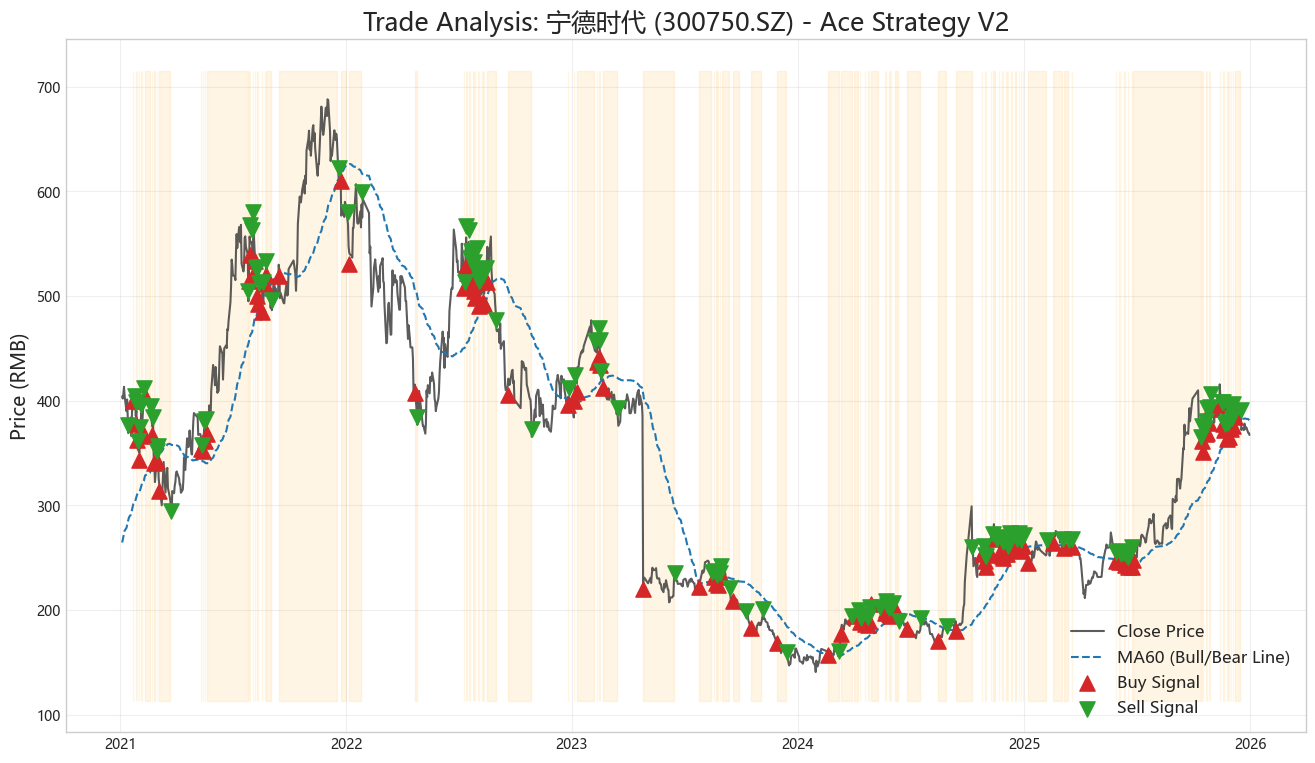

正在绘制贵州茅台的交易详情...


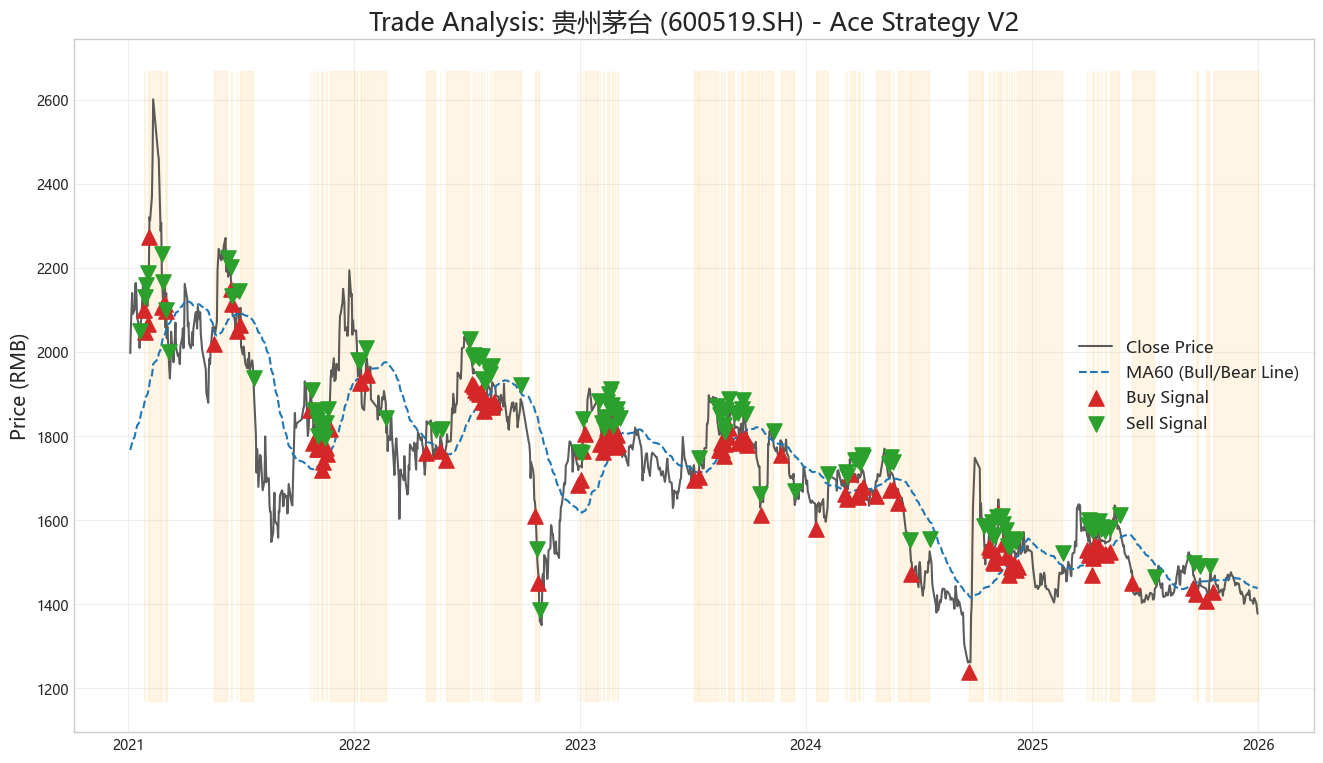

In [11]:
def plot_trade_signals(name, code, start_date='2022-01-01', strategy_func=generate_ace_signals_v2):
    """
    绘制单只股票的买卖信号图
    """
    # 1. 加载并计算
    df = load_features_from_db(code)
    if df is None: return
    
    df = strategy_func(df) # 使用 V2 策略生成信号
    
    # 2. 截取展示时间段 (为了看清细节，默认看最近2-3年)
    plot_data = df.loc[start_date:].copy()
    
    plt.figure(figsize=(16, 9))
    
    # 主图: 股价与均线
    plt.plot(plot_data.index, plot_data['close'], label='Close Price', color='#333333', linewidth=1.5, alpha=0.8)
    plt.plot(plot_data.index, plot_data['MA60'], label='MA60 (Bull/Bear Line)', color='#1f77b4', linestyle='--', linewidth=1.5)
    
    # 填充牛熊背景 (可选)
    # plt.fill_between(plot_data.index, plot_data['close'].min(), plot_data['close'].max(), 
    #                  where=(plot_data['close'] > plot_data['MA60']), color='red', alpha=0.05, label='Bull Zone')
    
    # 提取买卖点
    buy_signals = plot_data[plot_data['signal'] == 1]
    sell_signals = plot_data[plot_data['signal'] == -1]
    
    # 绘制买入信号 (红色向上三角)
    plt.scatter(buy_signals.index, buy_signals['close'] * 0.98, marker='^', color='#d62728', s=120, label='Buy Signal', zorder=10)
    
    # 绘制卖出信号 (绿色向下三角)
    plt.scatter(sell_signals.index, sell_signals['close'] * 1.02, marker='v', color='#2ca02c', s=120, label='Sell Signal', zorder=10)
    
    # 标注卖出原因 (简易版)
    for date, row in sell_signals.iterrows():
        # 如果是 V3，卖出可能是止损、移动止盈或死叉
        # 这里仅做简单标注
        pass
        # plt.text(date, row['close']*1.05, 'Exit', fontsize=9, ha='center', color='green')

    plt.title(f'Trade Analysis: {name} ({code}) - Ace Strategy V2', fontsize=18)
    plt.ylabel('Price (RMB)', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    
    # 绘制副图：持仓状态 (背景色)
    # 获取 "持有中" 的时间段并染色
    # 需要重构 continuous position 序列
    
    # 快速重算 position 列用于画图
    pos = 0
    plot_data['pos_state'] = 0
    for i in range(len(plot_data)):
        sig = plot_data['signal'].iloc[i]
        if sig == 1: pos = 1
        elif sig == -1: pos = 0
        plot_data.iloc[i, plot_data.columns.get_loc('pos_state')] = pos
        
    # shift(1) 修正: 信号当日不持有? 或者简单起见，画出信号后的持有区
    # 为了视觉效果，直接画出 pos_state=1 的区域
    
    ylim = plt.gca().get_ylim()
    plt.fill_between(plot_data.index, ylim[0], ylim[1], 
                     where=(plot_data['pos_state']==1), 
                     color='orange', alpha=0.1, label='Holding Period')
    
    plt.savefig(f'题目二_stock_analysis_plots/trade_detail_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 选取波动性较好的"宁德时代"进行展示
print("正在绘制宁德时代的交易详情...")
plot_trade_signals('宁德时代', target_stocks['宁德时代'], start_date='2021-01-01')

# 选取趋势性较好的"贵州茅台"进行展示
print("正在绘制贵州茅台的交易详情...")
plot_trade_signals('贵州茅台', target_stocks['贵州茅台'], start_date='2021-01-01')

# 12. 扩展性验证：不同风格10只股票回测 (Diverse Portfolio Test)

为了验证策略在不同市场风格下的普适性，我们**手动精选**了 10 只具有代表性的股票进行测试。
这些股票涵盖了：
*   **大盘蓝筹**: 招商银行 (低估值)、中国平安 (综合金融)
*   **成长赛道**: 恒瑞医药 (医疗龙头)、迈瑞医疗 (器械龙头)
*   **科技/制造**: 立讯精密 (高端制造)、海康威视 (安防龙头)
*   **周期/资源**: 万华化学 (化工茅)、紫金矿业 (有色金属)
*   **稳健防御**: 伊利股份 (乳业龙头)、长江电力 (水电航母)

**测试目标**: 观察 Ace V2 策略是否能适应各种性格的股票。我们将构建一个**等权重组合**，并将其表现与**等权重的买入持有策略 (Buy & Hold)** 进行对比（注：为了更公平地反映选股能力，此处不再对比市值加权的HS300指数，而是对比这10只股票自身的自然表现）。

开始对精选的 10 只多元化股票进行回测 (2020至今)...
正在获取基准指数数据: 000300.SH ...

=== 个股收益对比: 策略 vs 躺平 ===


,Auto-Trade,Buy&Hold,Alpha,MaxDD
Stock,,,,
工商银行,24.39%,32.83%,-8.44%,-28.01%
农业银行,108.61%,105.90%,2.71%,-14.36%
中国银行,37.10%,54.03%,-16.94%,-21.52%
长江电力,13.93%,55.91%,-41.97%,-26.47%
华能水电,87.03%,113.15%,-26.12%,-27.92%
中国铝业,996.77%,239.44%,757.33%,-23.86%
鞍钢股份,-9.93%,-24.70%,14.77%,-52.71%
中远海控,295.08%,183.21%,111.87%,-39.52%
中国石油,43.33%,77.34%,-34.01%,-51.08%


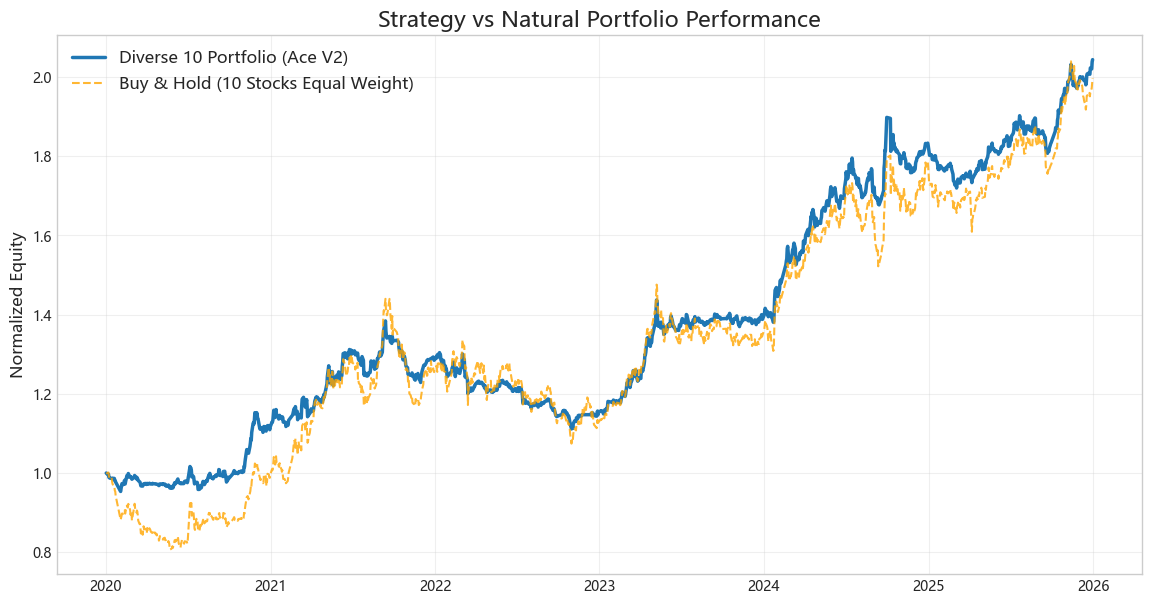


组合总收益 (V2): 104.39%
组合总收益 (持有): 99.69%
超额收益 (Alpha): 4.69%


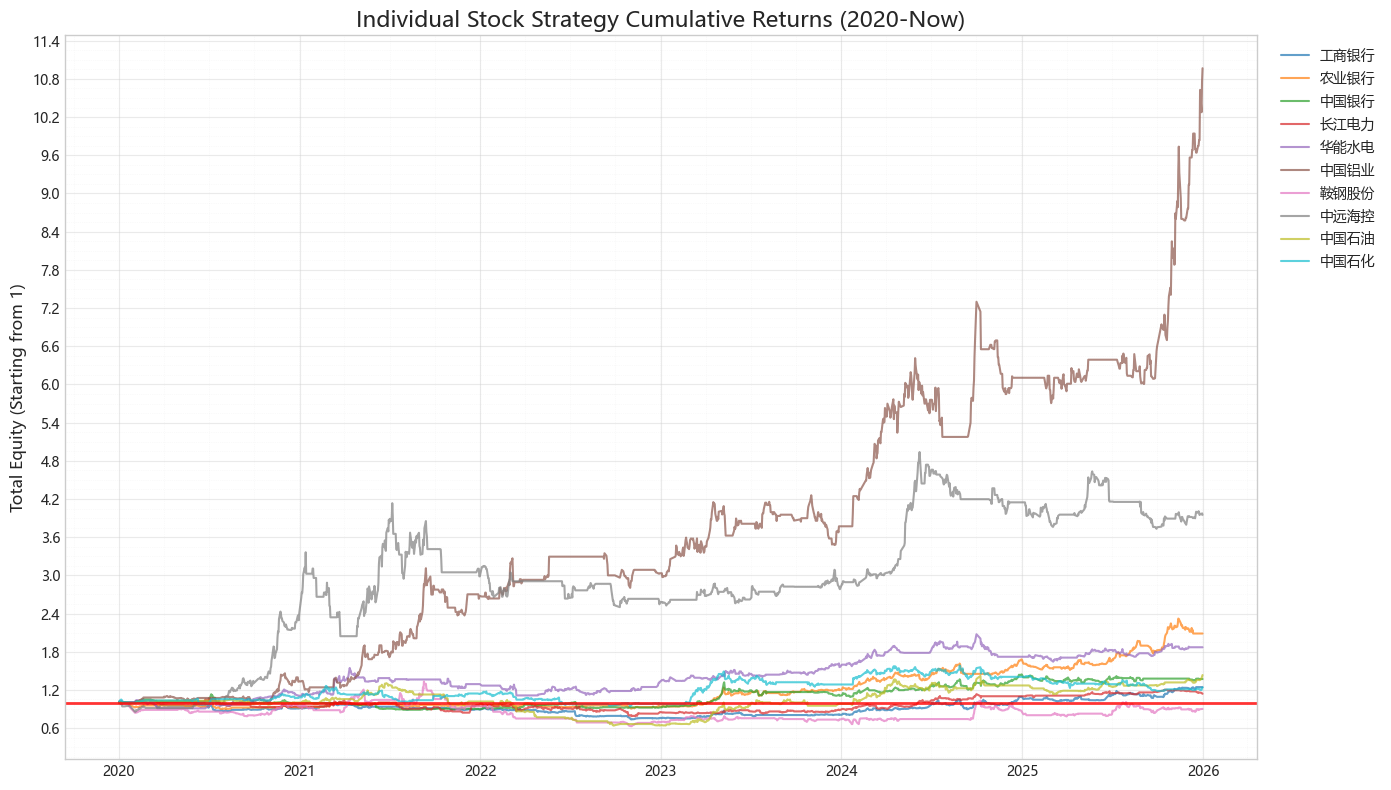

In [12]:

# 收益≈0 的对冲型股票池 (10只)
diverse_stocks = {
    # 防御型（熊市抗跌，牛市滞涨）
    '工商银行': '601398.SH',   # 大银行，长期横盘
    '农业银行': '601288.SH',   # 大银行
    '中国银行': '601988.SH',   # 大银行
    '长江电力': '600900.SH',   # 公用事业，稳定低波动
    '华能水电': '600025.SH',   # 电力

    # 高波动周期型（牛市暴涨，熊市暴跌）
    '中国铝业': '601600.SH',   # 有色周期
    '鞍钢股份': '000898.SZ',   # 钢铁周期
    '中远海控': '601919.SH',   # 航运周期
    '中国石油': '601857.SH',   # 油气，长期低迷
    '中国石化': '600028.SH',   # 油气
}
print(f"开始对精选的 {len(diverse_stocks)} 只多元化股票进行回测 (2020至今)...")

results_summary = []
# 用于存储组合收益
portfolio_strategy = pd.DataFrame()
portfolio_buyhold = pd.DataFrame()

bt_start_date = '2020-01-01'

for name, code in diverse_stocks.items():
    # 1. 加载
    df = load_features_from_db(code)
    if df is None: 
        print(f"数据缺失: {name}")
        continue
    
    # 2. 运行 V2 策略
    df = generate_ace_signals_v2(df)
    df = run_single_stock_backtest(df)
    
    # 3. 数据截取
    df_metrics = df.loc[bt_start_date:].copy()
    if df_metrics.empty: continue

    # 4. 计算收益序列 (用于组合)
    # 策略收益
    if portfolio_strategy.empty:
        portfolio_strategy = df_metrics[['strategy_ret']].rename(columns={'strategy_ret': name})
    else:
        portfolio_strategy = portfolio_strategy.join(df_metrics[['strategy_ret']].rename(columns={'strategy_ret': name}), how='outer')
        
    # 买入持有收益
    daily_ret = df_metrics['close'].pct_change().fillna(0)
    if portfolio_buyhold.empty:
        portfolio_buyhold = daily_ret.to_frame(name)
    else:
        portfolio_buyhold = portfolio_buyhold.join(daily_ret.to_frame(name), how='outer')

    # 5. 单股统计
    equity_s = (1 + df_metrics['strategy_ret']).cumprod()
    equity_b = (1 + daily_ret).cumprod()
    
    max_dd = (equity_s - equity_s.cummax()) / equity_s.cummax()
    
    results_summary.append({
        'Stock': name,
        'Auto-Trade': equity_s.iloc[-1] - 1,
        'Buy&Hold': equity_b.iloc[-1] - 1,
        'Alpha': (equity_s.iloc[-1] - 1) - (equity_b.iloc[-1] - 1),
        'MaxDD': max_dd.min()
    })

# === 组合层面计算 ===
portfolio_strategy.fillna(0, inplace=True)
portfolio_buyhold.fillna(0, inplace=True)

# 等权重平均收益
portfolio_strategy['pool_ret'] = portfolio_strategy.mean(axis=1)
portfolio_buyhold['pool_ret'] = portfolio_buyhold.mean(axis=1)

# 净值曲线
curve_strategy = (1 + portfolio_strategy['pool_ret']).cumprod()
curve_buyhold = (1 + portfolio_buyhold['pool_ret']).cumprod()

# 获取HS300作为外部参考 (可选)
hs300_ref = get_benchmark_data(start_date=bt_start_date)
common_idx = curve_strategy.index.intersection(hs300_ref.index)
curve_strategy = curve_strategy.loc[common_idx]
curve_buyhold = curve_buyhold.loc[common_idx]
curve_hs300 = hs300_ref.loc[common_idx, 'close']

# 归一化
curve_strategy = curve_strategy / curve_strategy.iloc[0]
curve_buyhold = curve_buyhold / curve_buyhold.iloc[0]
curve_hs300 = curve_hs300 / curve_hs300.iloc[0]

# === 1. 展示个股详情 ===
df_res = pd.DataFrame(results_summary).set_index('Stock')
# 格式化
df_disp = df_res.copy()
for c in df_disp.columns:
    df_disp[c] = df_disp[c].apply(lambda x: f"{x:.2%}")
print("\n=== 个股收益对比: 策略 vs 躺平 ===")
display(df_disp)

# === 2. 绘图: 策略 vs 10股等权基准 vs HS300 ===
plt.figure(figsize=(14, 7))

# 策略组合 (V2)
plt.plot(curve_strategy.index, curve_strategy, label='Diverse 10 Portfolio (Ace V2)', color='#1f77b4', linewidth=2.5)

# 自构建基准 (10股等权持有)
plt.plot(curve_buyhold.index, curve_buyhold, label='Buy & Hold (10 Stocks Equal Weight)', color='orange', linestyle='--', alpha=0.8)

# 市场基准 (HS300)
# plt.plot(curve_hs300.index, curve_hs300, label='HS300 Index', color='gray', linestyle=':', alpha=0.5)

plt.title('Strategy vs Natural Portfolio Performance', fontsize=16)
plt.ylabel('Normalized Equity', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('题目二_stock_analysis_plots/diverse_portfolio_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 计算组合指标
s_ret = curve_strategy.iloc[-1] - 1
b_ret = curve_buyhold.iloc[-1] - 1
print(f"\n组合总收益 (V2): {s_ret:.2%}")
print(f"组合总收益 (持有): {b_ret:.2%}")
print(f"超额收益 (Alpha): {s_ret - b_ret:.2%}")

# === 3. 附加绘图: 10只个股随时间的策略收益曲线 ===
plt.figure(figsize=(14, 8))

# 排除 'pool_ret' 列，仅绘制个股
stock_cols = [c for c in portfolio_strategy.columns if c != 'pool_ret']

for stock_name in stock_cols:
    # 计算单只股票的策略累计净值
    equity_curve = (1 + portfolio_strategy[stock_name]).cumprod() 
    plt.plot(equity_curve.index, equity_curve, label=stock_name, linewidth=1.5, alpha=0.7)

plt.title('Individual Stock Strategy Cumulative Returns (2020-Now)', fontsize=16)
plt.ylabel('Total Equity (Starting from 1)', fontsize=12)
# 将图例放置在图像外侧，避免遮挡
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

# === 增加纵坐标密度 ===
import matplotlib.ticker as ticker
ax = plt.gca()
# 设置主刻度数量更多 (例如最多20个间隔)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
# 开启次刻度
ax.minorticks_on()
# 显示主网格和次网格
plt.grid(True, which='major', alpha=0.4, linewidth=0.8)
plt.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)

# === 重点标记 Y=1.0 (盈亏平衡线) ===
plt.axhline(y=1.0, color='red', linestyle='-', linewidth=2, alpha=0.8, label='Break-even (1.0)')

plt.tight_layout()
plt.savefig('题目二_stock_analysis_plots/diverse_individual_stocks.png', dpi=300, bbox_inches='tight')
plt.show()